In [1]:
import numpy as np
import pandas as pd
import random
import missingno
from sklearn.linear_model import LogisticRegression
import sys
import math
import pickle

from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.impute import KNNImputer
from imblearn.under_sampling import NearMiss 
from imblearn.over_sampling import BorderlineSMOTE

sys.path.insert(0, "../../../Modules")

pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import *
enc = 'utf-8'

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
NUTS0 = 'IT'
NUTS2 = 'Veneto'

In [4]:
f = open(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_2008-2019_Cases_Dates.txt", "r")
print(f.read())

months: 6, 7, 8, 9, 10, 11, 
years: 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 


In [5]:
r_u = 0.05
near_u = 0.35
smote = 1
scaler = 'minmax'
weight_multiplier = 1
#years_to_remove = [2014, 2015, 2016, 2017]
years_to_remove = []
features_to_remove = ['day', 'month', 'week', 'year']
#features_to_remove = []
path = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2008_2019.csv'

In [6]:
dataset = read_data(path)
dataset.head()

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,population,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,11.79324,45.35865,2008-01-01,veneto,abano terme,1,1,1,2008,0.201299,0.97953,0.5,0.866025,0.118273,0.992981,"19,349",46.86670,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8982.126981,2074.539971,3,170.409233,10.722186,179.966181,0.0,1.063084,31.0,99.0,36.0,99.0,30.0,99.0,12,12.0,1.0,6.0,7.0,2,0,1,0,0
1,12.04199,45.06525,2008-01-01,veneto,adria,1,1,1,2008,0.201299,0.97953,0.5,0.866025,0.118273,0.992981,"20,233",46.64640,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6701.380530,1644.125334,2,145.603087,-1.354496,180.070371,0.0,1.206604,31.0,99.0,36.0,99.0,30.0,99.0,12,12.0,1.0,6.0,7.0,2,0,1,0,0
2,10.77673,45.55680,2008-01-01,veneto,affi,1,1,1,2008,0.201299,0.97953,0.5,0.866025,0.118273,0.992981,"2,297",46.81410,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5306.025387,738.794180,6,207.641691,201.821006,178.733735,0.0,1.815834,22.0,90.0,20.0,90.0,20.0,90.0,9,9.0,4.0,1.0,1.0,2,0,1,0,0
3,11.96539,45.17531,2008-01-01,veneto,agna,1,1,1,2008,0.201299,0.97953,0.5,0.866025,0.118273,0.992981,"3,400",46.73306,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16631.850238,1165.197945,3,121.193871,0.122498,180.188821,0.0,3.769479,31.0,99.0,36.0,99.0,30.0,99.0,12,12.0,1.0,6.0,7.0,2,0,1,0,0
4,12.04755,46.30297,2008-01-01,veneto,agordo,1,1,1,2008,0.201299,0.97953,0.5,0.866025,0.118273,0.992981,"4,249",47.84463,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15023.566702,684.464446,18,124.001040,1470.386475,152.701532,0.0,2.289867,15.0,92.0,10.0,91.0,10.0,91.0,5,5.0,7.0,1.0,1.0,2,0,1,0,0


In [7]:
dataset = dataset.query('month >= 6 & month <= 11')
dataset.reset_index(inplace=True, drop=True)

In [8]:
dataset

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,population,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,11.79324,45.35865,2008-06-01,veneto,abano terme,1,6,22,2008,0.201299,0.979530,1.224647e-16,-1.000000,0.508531,-0.861044,"19,349",46.86670,0.401519,0.140618,-0.237628,-0.140618,0.346393,0.086866,-0.258230,-0.086866,0.056313,0.043306,0.015045,0.043306,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8982.126981,2074.539971,3,170.409233,10.722186,179.966181,0.000000,1.063084,31.0,99.0,36.0,99.0,30.0,99.0,12,12.0,1.0,6.0,7.0,2,0,326,367,0
1,12.04199,45.06525,2008-06-01,veneto,adria,1,6,22,2008,0.201299,0.979530,1.224647e-16,-1.000000,0.508531,-0.861044,"20,233",46.64640,0.414457,0.179162,-0.238327,-0.179162,0.350741,0.114055,-0.246029,-0.114055,0.145941,0.160425,0.042403,0.160425,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6701.380530,1644.125334,2,145.603087,-1.354496,180.070371,0.000000,1.206604,31.0,99.0,36.0,99.0,30.0,99.0,12,12.0,1.0,6.0,7.0,2,0,371,447,0
2,10.77673,45.55680,2008-06-01,veneto,affi,1,6,22,2008,0.201299,0.979530,1.224647e-16,-1.000000,0.508531,-0.861044,"2,297",46.81410,0.453163,0.214368,-0.218987,-0.214368,0.498889,0.203807,-0.264907,-0.203807,0.053675,0.050346,0.024386,0.050346,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5306.025387,738.794180,6,207.641691,201.821006,178.733735,0.000000,1.815834,22.0,90.0,20.0,90.0,20.0,90.0,9,9.0,4.0,1.0,1.0,2,0,33,44,0
3,11.96539,45.17531,2008-06-01,veneto,agna,1,6,22,2008,0.201299,0.979530,1.224647e-16,-1.000000,0.508531,-0.861044,"3,400",46.73306,0.330621,0.065681,-0.279323,-0.065681,0.332201,0.068339,-0.278148,-0.068339,0.065406,0.061280,0.013125,0.061280,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16631.850238,1165.197945,3,121.193871,0.122498,180.188821,0.000000,3.769479,31.0,99.0,36.0,99.0,30.0,99.0,12,12.0,1.0,6.0,7.0,2,0,314,541,0
4,12.04755,46.30297,2008-06-01,veneto,agordo,1,6,22,2008,0.201299,0.979530,1.224647e-16,-1.000000,0.508531,-0.861044,"4,249",47.84463,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15023.566702,684.464446,18,124.001040,1470.386475,152.701532,0.000000,2.289867,15.0,92.0,10.0,91.0,10.0,91.0,5,5.0,7.0,1.0,1.0,2,0,28,41,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82242,12.17878,46.38835,2019-11-16,veneto,zoppe da cadore,16,11,46,2019,-0.101168,-0.994869,-5.000000e-01,0.866025,-0.737833,0.674983,265,47.96042,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,25000.599626,346.378682,37,238.788886,1403.106042,162.646151,0.000000,2.557130,15.0,94.0,10.0,96.0,10.0,96.0,5,5.0,6.0,4.0,4.0,2,0,1,19,0
82243,11.49430,45.43798,2019-11-16,veneto,zovencedo,16,11,46,2019,-0.101168,-0.994869,-5.000000e-01,0.866025,-0.737833,0.674983,796,46.86928,0.571322,0.155106,-0.465696,-0.155106,0.548208,0.162205,-0.425753,-0.162205,0.051183,0.051136,0.085044,0.051136,8.62,11.25,5.99,4.295000,-0.508182,11.538000,3.365556,18.535455,6.696667,19.732,10.316667,227.983651,343.831703,1972.511516,5077.714670,1967.854592,35,131.888403,267.495086,193.006806,0

In [9]:
dataset['lau1'].unique().shape

(571,)

In [10]:
dsc = dataframe_describe(dataset)
dsc.head(15)

,year,non-case,case,total,percentage
0,2008,6851,1,6852,8.33%
1,2009,6846,6,6852,8.33%
2,2010,6845,7,6852,8.33%
3,2011,6843,9,6852,8.33%
4,2012,6823,32,6855,8.33%
5,2013,6826,27,6853,8.33%
6,2014,6850,2,6852,8.33%
7,2015,6851,1,6852,8.33%
8,2016,6843,9,6852,8.33%
9,2017,6837,16,6853,8.33%


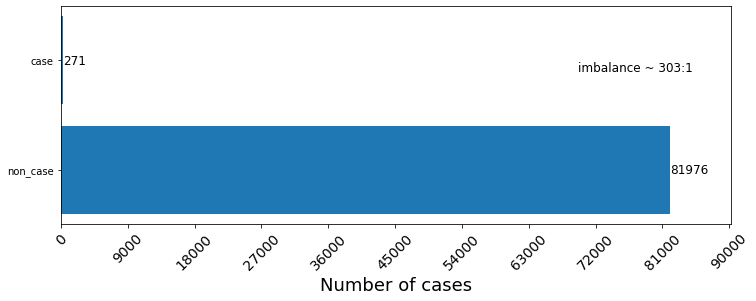

In [11]:
plot_imbalance(dataset)

In [12]:
coefficients = []
results_train = pd.DataFrame()
results_test = pd.DataFrame()
feature_names = dataset.select_dtypes(exclude=['object']).drop(columns = ['case']).columns

In [13]:
for train_idx, test_idx in yearCV_split(dataset, exclude_years_train=years_to_remove):
    data_train = dataset.iloc[train_idx]
    data_test = dataset.iloc[test_idx]
    
    data_train.reset_index(inplace = True, drop = True)
    data_test.reset_index(inplace = True, drop = True)
    
    X_train = data_train.select_dtypes(exclude=['object']).drop(columns = ['case'])
    X_train.drop(columns = features_to_remove)
    y_train = data_train['case']
    X_test = data_test.select_dtypes(exclude=['object']).drop(columns = ['case'])
    y_test = data_test['case']
    
    X_train, X_test, y_train, y_test, X_train_df, scaler, imputer, nm, sm = transform_data(X_train, X_test, y_train, y_test, r_u, near_u, smote, scaler_key=scaler)
    w0,w1 = calculate_weights(y_train)
    w1 = w1*weight_multiplier

    model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)

    trained_model = train_lin_model(model, X_train, y_train)
    
    train, test, coef = predict_lin_model(trained_model, X_train_df, data_test, X_train, y_train, X_test, y_test)
    
    results_train = results_train.append(train, ignore_index = True)
    results_test = results_test.append(test, ignore_index = True)
    coefficients.append(coef)
    
    print(f"Year: {test['year'].iloc[0]} || w0:{w0}, w1:{w1} || ##")

Year: 2008 || w0:1, w1:89 || ##
Year: 2009 || w0:1, w1:91 || ##
Year: 2010 || w0:1, w1:91 || ##
Year: 2011 || w0:1, w1:92 || ##
Year: 2012 || w0:1, w1:100 || ##
Year: 2013 || w0:1, w1:98 || ##
Year: 2014 || w0:1, w1:89 || ##
Year: 2015 || w0:1, w1:89 || ##
Year: 2016 || w0:1, w1:92 || ##
Year: 2017 || w0:1, w1:94 || ##
Year: 2018 || w0:1, w1:165 || ##
Year: 2019 || w0:1, w1:102 || ##


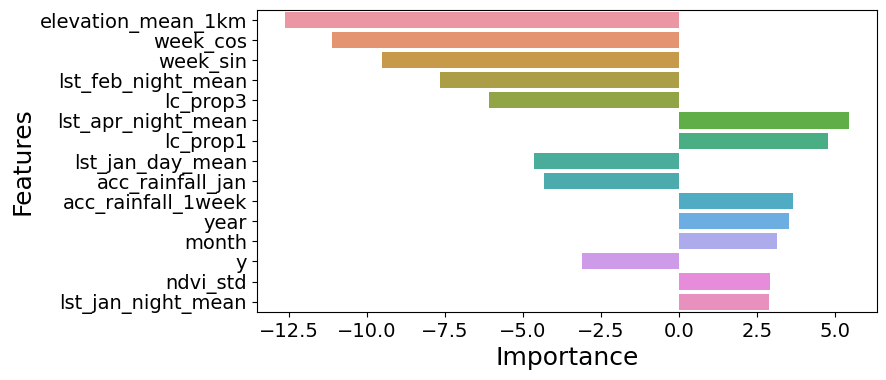

In [14]:
plot_feature_importance(coefficients, feature_names, top = 15, figure_size = (8, 4))

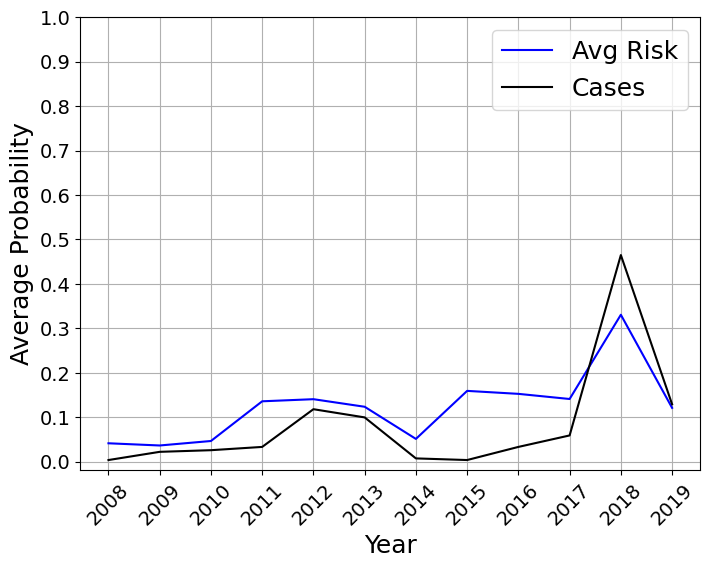

In [15]:
plot_trend_curve(results_test, score_col='score', cases=list(dsc['case']))

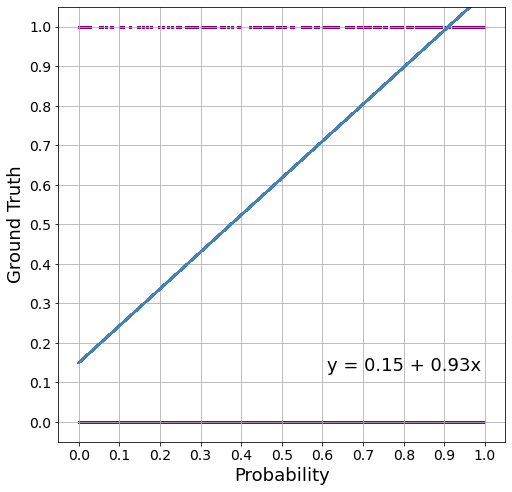

In [16]:
plot_probability_curve(results_test)

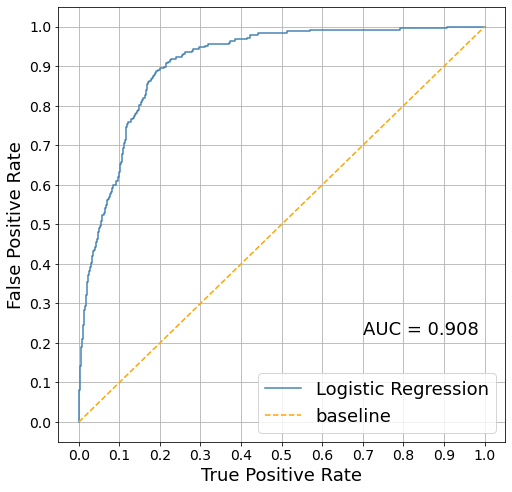

In [17]:
plot_roc_curve(results_test)

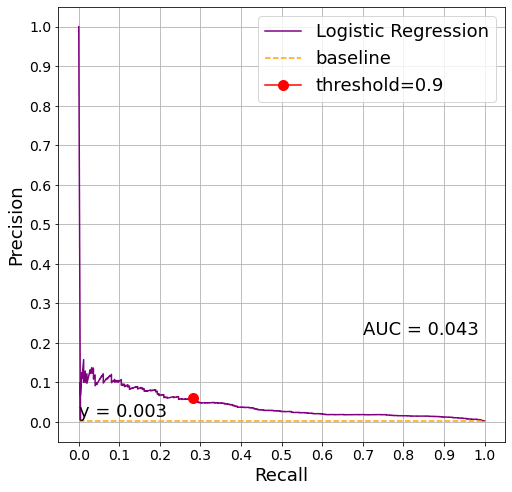

In [18]:
plot_pr_curve(results_test, plot_fbeta = True)


In [19]:
operational, cumulative, avg, weighted, r_avg, r_weighted = evaluate_operational(results_test, k = 100, ouput_random = True, sampling_number=100)
print(f'Average: {avg*100:.2f}%\nWeighted Average: {weighted*100:.2f}%')
print(f'\nRandom Average: {r_avg*100:.2f}%\nRandom Weighted Average: {r_weighted*100:.2f}%')

Average: 34.91%
Weighted Average: 33.87%

Random Average: 17.36%
Random Weighted Average: 17.67%


In [20]:
operational

,Prediction Date,Infected,Discovered,Random Discovered,Out of,Percentage,percentage,Random Percentage,random percentage
0,01/06/2008,0,0,0.00,0,NaN,NaN,NaN,NaN
1,16/06/2008,0,0,0.00,0,NaN,NaN,NaN,NaN
2,01/07/2008,0,0,0.00,0,NaN,NaN,NaN,NaN
3,16/07/2008,0,0,0.00,0,NaN,NaN,NaN,NaN
4,01/08/2008,0,0,0.00,0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
139,16/09/2019,5,2,1.00,5,40.00 %,0.4,20.00 %,0.20
140,01/10/2019,1,1,0.21,1,100.00 %,1.0,21.00 %,0.21
141,16/10/2019,0,0,0.00,0,NaN,NaN,NaN,NaN
142,01/11/2019,0,0,0.00,0,NaN,NaN,NaN,NaN


In [21]:
cumulative

,Year,Infected,Discovered,Random Discovered,Out Of,Percentage,percentage,Random Percentage,random percentage
0,2008,1,1,0.16,1,100.00 %,1.0000,16.00 %,0.1600
1,2009,6,3,1.15,6,50.00 %,0.5000,19.17 %,0.1917
2,2010,7,3,1.25,7,42.86 %,0.4286,17.86 %,0.1786
3,2011,9,0,1.67,9,0.00 %,0.0000,18.56 %,0.1856
4,2012,29,13,4.95,29,44.83 %,0.4483,17.07 %,0.1707
5,2013,26,7,4.42,26,26.92 %,0.2692,17.00 %,0.1700
6,2014,2,0,0.32,2,0.00 %,0.0000,16.00 %,0.1600
7,2015,1,0,0.15,1,0.00 %,0.0000,15.00 %,0.1500
8,2016,9,5,1.69,9,55.56 %,0.5556,18.78 %,0.1878
9,2017,15,6,2.58,15,40.00 %,0.4000,17.20 %,0.1720


In [22]:
results_test

,x,y,lau1,day,month,year,case,score
0,12.64550,45.53937,jesolo,16,8,2018,0,9.989788e-01
1,12.64884,45.68374,ceggia,16,8,2018,0,9.982185e-01
2,12.62107,45.75752,motta da livenza,16,8,2018,0,9.980037e-01
3,12.54296,45.67127,noventa da piave,16,8,2018,0,9.979486e-01
4,12.89482,45.63839,caorle,16,8,2018,0,9.974389e-01
...,...,...,...,...,...,...,...,...
82219,11.93045,46.43842,rocca pietore,1,6,2008,0,4.362943e-12
82220,11.93045,46.43842,rocca pietore,1,6,2010,0,3.531329e-12
82221,12.11704,46.55724,cortina da ampezzo,1,6,2010,0,3.349093e-12
82222,11.85565,46.37360,falcade,1,6,2010,0,2.646350e-12


In [23]:
report_train, report_test = classification_report(results_train, results_test, threshold = 0.2, beta = 4)

In [24]:
report_test.head(15)

,Year,Infected,Positive Rate,Accuracy,Precision,Recall,F4 Score,Loss
0,2008,1.0000,0.0679,0.9661,0.0022,1.0000,0.0353,0.0508
1,2009,6.0000,0.0534,0.6401,0.0055,0.3333,0.0736,0.0463
2,2010,7.0000,0.0810,0.6740,0.0054,0.4286,0.0765,0.0608
3,2011,9.0000,0.2293,0.8859,0.0057,1.0000,0.0892,0.2177
4,2012,29.0000,0.2436,0.8625,0.0168,0.9655,0.2232,0.2124
5,2013,26.0000,0.2329,0.8271,0.0144,0.8846,0.1943,0.1818
6,2014,2.0000,0.0873,0.7064,0.0017,0.5000,0.0270,0.0653
7,2015,1.0000,0.2634,0.8683,0.0006,1.0000,0.0093,0.2551
8,2016,9.0000,0.2602,0.8704,0.0050,1.0000,0.0794,0.2362
9,2017,15.0000,0.2405,0.8472,0.0085,0.9333,0.1261,0.2193


In [25]:
results_test

,x,y,lau1,day,month,year,case,score
0,12.64550,45.53937,jesolo,16,8,2018,0,9.989788e-01
1,12.64884,45.68374,ceggia,16,8,2018,0,9.982185e-01
2,12.62107,45.75752,motta da livenza,16,8,2018,0,9.980037e-01
3,12.54296,45.67127,noventa da piave,16,8,2018,0,9.979486e-01
4,12.89482,45.63839,caorle,16,8,2018,0,9.974389e-01
...,...,...,...,...,...,...,...,...
82219,11.93045,46.43842,rocca pietore,1,6,2008,0,4.362943e-12
82220,11.93045,46.43842,rocca pietore,1,6,2010,0,3.531329e-12
82221,12.11704,46.55724,cortina da ampezzo,1,6,2010,0,3.349093e-12
82222,11.85565,46.37360,falcade,1,6,2010,0,2.646350e-12


In [26]:
results_test[['x', 'y', 'day', 'month', 'year']].value_counts()

x         y         day  month  year
10.67387  45.43843  1    6      2008    1
11.97110  45.86503  1    9      2015    1
                    16   8      2013    1
                                2012    1
                                2011    1
                                       ..
11.54614  45.22066  1    9      2018    1
                                2017    1
                                2016    1
                                2015    1
13.00835  45.68095  16   11     2019    1
Length: 82224, dtype: int64

In [27]:
results_test.to_csv(f"../../data/{NUTS2}/results/{NUTS0}_{NUTS2}_Results_2008-2019.csv", encoding = enc, index = False)

In [28]:
scalers = {'minmax': MinMaxScaler(),
               'standard': StandardScaler(),
               'robust': RobustScaler(),
               'abs': MaxAbsScaler()}

data_train = dataset.loc[~dataset['year'].isin(years_to_remove)]
data_train.reset_index(inplace = True, drop = True)

X_train = data_train.select_dtypes(exclude=['object']).drop(columns = ['case'])
X_train.drop(columns = features_to_remove)
y_train = data_train['case']

if(r_u != 0):
    nan_index = []
    zero_index = []
        
    for index, row in X_train.iterrows():
        if row.isnull().values.any():
            nan_index.append(index)
            if y_train.iloc[index] == 0:
                zero_index.append(index)
            
    nan_set = set(nan_index)
    zero_set = set(zero_index)
        
    intersection = list(nan_set.intersection(zero_set))
    sampling_size = math.ceil(len(intersection) * r_u)
    removed = random.sample(intersection, sampling_size)
        
    X_train = X_train.drop(index = removed, axis = 1)
    y_train = y_train.drop(index = removed, axis = 1)

scaler = scalers.get(scaler, MinMaxScaler())
X_train = scaler.fit_transform(X_train)
    
imputer = KNNImputer()
X_train = imputer.fit_transform(X_train)

try:
    class_0_counts = y_train.value_counts()[0]
except KeyError:
    class_0_counts = 0
try:
    class_1_counts = y_train.value_counts()[1]
except KeyError:
    class_1_counts = 0

if (near_u != 0):
    nm = NearMiss(sampling_strategy = {0: math.ceil(class_0_counts * (1 - near_u)), 1: class_1_counts}, version = 1, n_jobs = -1)
    X_train, y_train = nm.fit_resample(X_train, y_train)

if (smote != 0):
    class_0_counts = y_train.value_counts()[0]
    sm = BorderlineSMOTE(sampling_strategy = {0: class_0_counts, 1: math.ceil(class_1_counts * (1 + smote))}, n_jobs = -1, random_state = 0)
    X_train, y_train = sm.fit_resample(X_train, y_train)

In [29]:
w0,w1 = calculate_weights(y_train)
w1 = w1*weight_multiplier

model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)

trained_model = train_lin_model(model, X_train, y_train)

In [30]:
trained_model

LogisticRegression(class_weight={0.0: 1, 1.0: 97}, max_iter=1000, n_jobs=-1,
                   random_state=0)

In [31]:
pickle.dump(trained_model, open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Linear_model.pkl', 'wb'))
pickle.dump(imputer, open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Imputer.pkl', 'wb'))
pickle.dump(scaler, open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Scaler.pkl', 'wb'))